# 🥋 Poser — Dual-Stem Feature Fusion Network
**Architecture:** Keras Functional API · Two Bi-LSTM Stems · Multi-Head Attention · Anti-Leakage Clip-Level Split  
**Classes:** GedanBarai · Gyakudzuki · MaeGeri

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
BG_COLOR = '#0D1117'
PALETTE  = {'GedanBarai': '#00C9FF', 'Gyakudzuki': '#FF6B6B', 'MaeGeri': '#A8FF78'}

TensorFlow  : 2.18.0
Keras       : 3.12.0
GPU devices : []


## § 1 — Feature Column Definitions

In [2]:
# Upper Body: landmarks 11-22 (x,y,z,v) + angle_08 to angle_13
UPPER_COORDS = [f'{c}{i}' for i in range(11, 23) for c in ['x', 'y', 'z', 'v']]
UPPER_ANGLES = [f'angle_{i:02d}' for i in range(8, 14)]
UPPER_FEATS  = UPPER_COORDS + UPPER_ANGLES   # 48 + 6 = 54

# Lower Body: landmarks 23-32 (x,y,z,v) + angle_00 to angle_07
LOWER_COORDS = [f'{c}{i}' for i in range(23, 33) for c in ['x', 'y', 'z', 'v']]
LOWER_ANGLES = [f'angle_{i:02d}' for i in range(0, 8)]
LOWER_FEATS  = LOWER_COORDS + LOWER_ANGLES   # 40 + 8 = 48

SEQ_LEN        = 30
N_CLASSES      = 3
N_UPPER        = len(UPPER_FEATS)   # 54
N_LOWER        = len(LOWER_FEATS)   # 48

print(f'Upper features: {N_UPPER}  (target 54)')
print(f'Lower features: {N_LOWER}  (target 48)')

Upper features: 54  (target 54)
Lower features: 48  (target 48)


## § 2 — Anti-Leakage Data Loader
Split is done at **clip level**, ensuring no video's frames span both train and test sets.

In [3]:
# ── 2. Anti-Leakage SUBJECT-LEVEL Split (Practitioner Isolation) ─────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

CSV_PATH = r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\data\karate_normalized_base.csv"
df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# ─ Label encode ──────────────────────────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['folder_label'])
CLASS_NAMES = le.classes_.tolist()
print(f'Classes: {CLASS_NAMES}')

# ─ Extract Practitioner and View ─────────────────────────────────────────────
def extract_practitioner_and_view(clip_name):
    parts = clip_name.split('_')
    if len(parts) >= 4:
        return parts[2], parts[1] # practitioner_id, view
    return "Unknown", "Unknown"

clip_meta = []
for clip_id, group in df.groupby('clip_id'):
    practitioner, view = extract_practitioner_and_view(clip_id)
    clip_meta.append({
        'clip_id': clip_id,
        'label_enc': group['label_enc'].iloc[0],
        'folder_label': group['folder_label'].iloc[0],
        'practitioner_id': practitioner,
        'view': view
    })
meta_df = pd.DataFrame(clip_meta)

# ── THE FIX: MANUAL GOLDEN TEST SET OVERRIDE ─────────────────────────────────
golden_test_practitioners = {'008', '027', '014', '037'}

test_mask = meta_df['practitioner_id'].isin(golden_test_practitioners)
train_mask = ~test_mask

train_meta = meta_df[train_mask]
test_meta = meta_df[test_mask]

train_clips = train_meta['clip_id'].values
test_clips = test_meta['clip_id'].values

# ─ Verification Checks ───────────────────────────────────────────────────────
print("\n📊 TRAINING SET BALANCE:")
print(pd.crosstab(train_meta['folder_label'], train_meta['view'], margins=True))

print("\n📊 TESTING SET BALANCE:")
print(pd.crosstab(test_meta['folder_label'], test_meta['view'], margins=True))

train_practitioners = set(train_meta['practitioner_id'])
test_practitioners = set(test_meta['practitioner_id'])
leakage = train_practitioners.intersection(test_practitioners)
print(f"\n🛡️ Subject Leakage Check:")
print(f"   Train Humans: {train_practitioners}")
print(f"   Test Humans:  {test_practitioners}")
print(f"   Overlapping Humans: {'✅ ZERO' if not leakage else f'❌ LEAK DETECTED: {leakage}'}")

# ─ Reconstruct frame-level sets ───────────────────────────────────────────────
train_df = df[df['clip_id'].isin(train_clips)].sort_values(['clip_id', 'frame_idx'])
test_df  = df[df['clip_id'].isin(test_clips)].sort_values(['clip_id', 'frame_idx'])

# ─ Builder function ───────────────────────────────────────────────────────────
def build_sequences(sub_df, features):
    clips = sub_df['clip_id'].unique()
    X = np.zeros((len(clips), SEQ_LEN, len(features)), dtype=np.float32)
    y = np.zeros(len(clips), dtype=np.int32)
    for i, clip in enumerate(clips):
        grp = sub_df[sub_df['clip_id'] == clip].sort_values('frame_idx')
        frames = grp[features].values
        X[i, :len(frames)] = frames[:SEQ_LEN]
        y[i] = grp['label_enc'].iloc[0]
    return X, y

print('\nBuilding 3D Tensors...')
X_train_upper, y_train = build_sequences(train_df, UPPER_FEATS)
X_train_lower, _       = build_sequences(train_df, LOWER_FEATS)
X_test_upper,  y_test  = build_sequences(test_df,  UPPER_FEATS)
X_test_lower,  _       = build_sequences(test_df,  LOWER_FEATS)

# ── THE FIX: Define ALL_FEATS for the baseline model ──
ALL_FEATS = UPPER_FEATS + LOWER_FEATS

# Build FULL features for the Baseline Single BiLSTM
X_train_full, _ = build_sequences(train_df, ALL_FEATS)
X_test_full, _  = build_sequences(test_df, ALL_FEATS)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f'Upper Train: {X_train_upper.shape} | Lower Train: {X_train_lower.shape}')
print(f'Baseline Full Train: {X_train_full.shape}')

Loaded: 13,380 rows × 149 cols
Classes: ['GedanBarai', 'Gyakudzuki', 'MaeGeri']

📊 TRAINING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       46    62  108
Gyakudzuki       33    83  116
MaeGeri          41   116  157
All             120   261  381

📊 TESTING SET BALANCE:
view          front  side  All
folder_label                  
GedanBarai       13     8   21
Gyakudzuki       13    13   26
MaeGeri          16     2   18
All              42    23   65

🛡️ Subject Leakage Check:
   Train Humans: {'031', '036', '022', '002', '041', '015', '007', '012', '006', '013', '034', '018', '009', '029', '035', '004', '003', '023', '021', '039', '017', '026', '020', '025', '019', '030', '032', '011', '038', '010', '005', '024', '001', '040', '033', '042', '016'}
   Test Humans:  {'027', '037', '008', '014'}
   Overlapping Humans: ✅ ZERO

Building 3D Tensors...
Upper Train: (381, 30, 54) | Lower Train: (381, 30, 48)
Baseline Full Train: (381, 30, 102)


## § 3 — Dual-Stem Fusion Architecture
```
Upper (30, 54) → BiLSTM(64) → Dropout → BiLSTM(32) ─┐
                                                       ├─ Concat → MultiHeadAttention(4 heads) → GlobalAvgPool → Dense(3)
Lower (30, 48) → BiLSTM(64) → Dropout → BiLSTM(32) ─┘
```

In [4]:
def build_dual_stem_model(
    n_upper=54, n_lower=48, seq_len=30, n_classes=3,
    lstm_units_1=64, lstm_units_2=32, num_heads=4, dropout_rate=0.4
):
    # ── Input 1: Upper Body ───────────────────────────────────────────────────
    inp_upper = keras.Input(shape=(seq_len, n_upper), name='upper_body')
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_upper_1'
    )(inp_upper)
    x_up = layers.Dropout(dropout_rate, name='drop_upper')(x_up)
    x_up = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_upper_2'
    )(x_up)

    # ── Input 2: Lower Body ───────────────────────────────────────────────────
    inp_lower = keras.Input(shape=(seq_len, n_lower), name='lower_body')
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_1, return_sequences=True),
        name='bilstm_lower_1'
    )(inp_lower)
    x_lo = layers.Dropout(dropout_rate, name='drop_lower')(x_lo)
    x_lo = layers.Bidirectional(
        layers.LSTM(lstm_units_2, return_sequences=True),
        name='bilstm_lower_2'
    )(x_lo)

    # ── Fusion Node ───────────────────────────────────────────────────────────
    fused = layers.Concatenate(axis=-1, name='fusion_concat')([x_up, x_lo])  # (batch, 30, 64+64)

    # ── Global Self-Attention (Sensei's Eye) ──────────────────────────────────
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=fused.shape[-1] // num_heads,
        name='sensei_attention'
    )(fused, fused)                               # self-attention
    attn_out = layers.LayerNormalization(name='attn_norm')(attn_out + fused)  # residual
    attn_out = layers.Dropout(0.3, name='drop_attn')(attn_out)

    # ── Readout ───────────────────────────────────────────────────────────────
    pooled = layers.GlobalAveragePooling1D(name='global_avg_pool')(attn_out)
    pooled = layers.Dense(64, activation='relu', name='pre_output')(pooled)
    pooled = layers.Dropout(0.3)(pooled)
    output = layers.Dense(n_classes, activation='softmax', name='technique_output')(pooled)

    model = Model(inputs=[inp_upper, inp_lower], outputs=output, name='DualStemFusion')
    return model

model = build_dual_stem_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "DualStemFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ upper_body          │ (None, 30, 54)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_body          │ (None, 30, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_1      │ (None, 30, 128)   │     60,928 │ upper_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_1      │ (None, 30, 128)   │     57,856 │ lower_body[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_upper          │ (None, 30, 128)   │          0 │ bilstm_upper_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lower          │ (None, 30, 128)   │          0 │ bilstm_lower_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_upper_2      │ (None, 30, 64)    │     41,216 │ drop_upper[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_lower_2      │ (None, 30, 64)    │     41,216 │ drop_lower[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 30, 128)   │          0 │ bilstm_upper_2[0… │
│ (Concatenate)       │                   │            │ bilstm_lower_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensei_attention    │ (None, 30, 128)   │     66,048 │ fusion_concat[0]… │
│ (MultiHeadAttentio… │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ sensei_attention… │
│                     │                   │            │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 30, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 30, 128)   │          0 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 128)       │          0 │ drop_attn[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output (Dense)  │ (None, 64)        │      8,256 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ pre_output[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ technique_output    │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 275,971 (1.05 MB)

 Trainable params: 275,971 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

## § 4 — Training

In [5]:
CKPT_PATH = 'dual_stem_best.keras'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

history = model.fit(
    x=[X_train_upper, X_train_lower],
    y=y_train_cat,
    validation_data=([X_test_upper, X_test_lower], y_test_cat),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4739 - loss: 1.1409
Epoch 1: val_accuracy improved from None to 0.83077, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.5538 - loss: 0.9790 - val_accuracy: 0.8308 - val_loss: 0.5701 - learning_rate: 0.0010
Epoch 2/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8457 - loss: 0.5209
Epoch 2: val_accuracy improved from 0.83077 to 0.87692, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8556 - loss: 0.4503 - val_accuracy: 0.8769 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 3/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9079 - loss: 0.2714
Epoch 3: val_accuracy improved from 0.87692 to 0.90769, saving model to dual_stem_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9344 - loss: 0.2256 - val_accuracy: 0.9077 - val_loss: 0.2494 - learning_rate: 0.0010
Epoch 4/150
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 41

##### ==============================================================================
#### ── 5. EVALUATE DUAL-STEM MODEL ───────────────────────────────────────────────
##### ==============================================================================


🔍 Evaluating Dual-Stem Model...

=== Dual-Stem Classification Report ===
              precision    recall  f1-score   support

  GedanBarai     1.0000    0.9048    0.9500        21
  Gyakudzuki     1.0000    1.0000    1.0000        26
     MaeGeri     0.9000    1.0000    0.9474        18

    accuracy                         0.9692        65
   macro avg     0.9667    0.9683    0.9658        65
weighted avg     0.9723    0.9692    0.9693        65



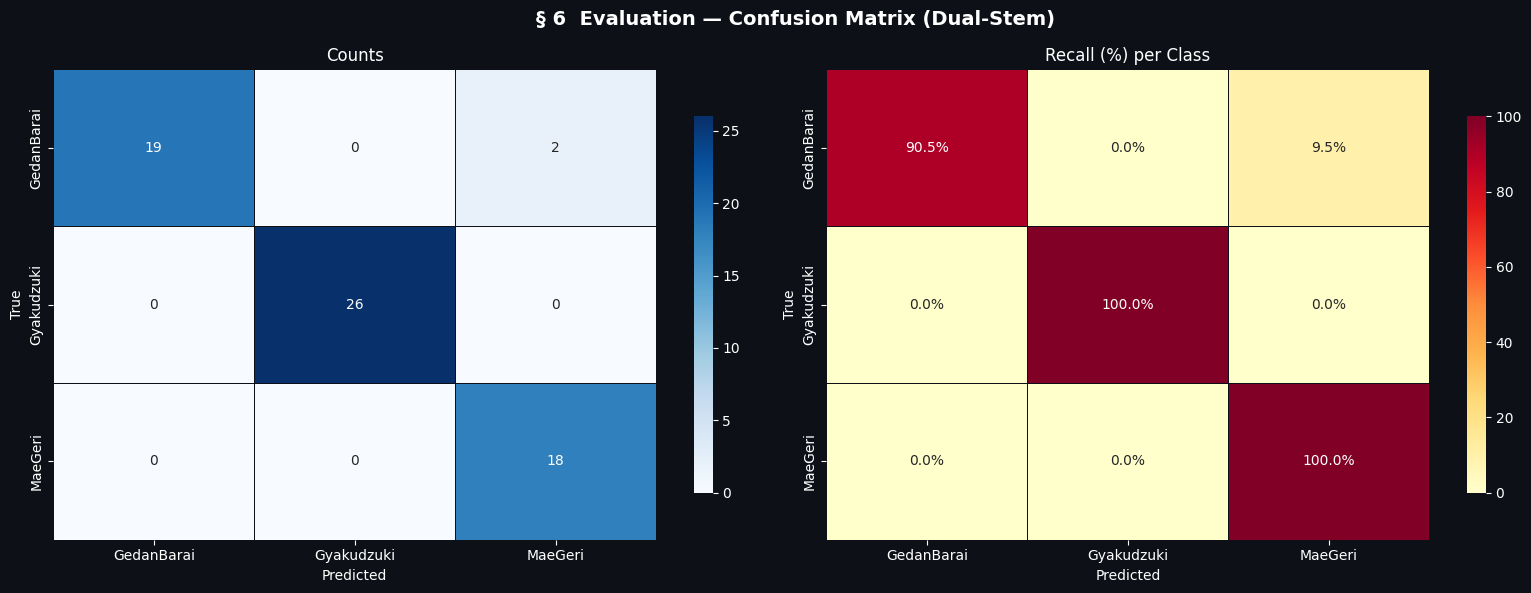


Dual-Stem Test Accuracy : 96.92%


In [6]:
import os
import json
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


print("\n🔍 Evaluating Dual-Stem Model...")
y_pred_probs = model.predict([X_test_upper, X_test_lower], verbose=0)
y_pred_new = np.argmax(y_pred_probs, axis=1)
y_true = y_test   # integer-encoded ground truth

print('\n=== Dual-Stem Classification Report ===')
print(classification_report(y_true, y_pred_new, target_names=CLASS_NAMES, digits=4))

# ─ Confusion Matrix (Seaborn) ─
cm = confusion_matrix(y_true, y_pred_new)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

BG_COLOR = '#0D1117'
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)
fig.suptitle('§ 6  Evaluation — Confusion Matrix (Dual-Stem)', fontsize=14, fontweight='bold', color='white')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#0D1117', ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Counts', color='white')
axes[0].set_xlabel('Predicted', color='white')
axes[0].set_ylabel('True', color='white')
axes[0].tick_params(colors='white')

# Percentage
annot_pct = np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
sns.heatmap(cm_pct, annot=annot_pct, fmt='', cmap='YlOrRd', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#0D1117', ax=axes[1], vmin=0, vmax=100, cbar_kws={'shrink': 0.8})
axes[1].set_title('Recall (%) per Class', color='white')
axes[1].set_xlabel('Predicted', color='white')
axes[1].set_ylabel('True', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

# Overall test accuracy
test_loss, test_acc = model.evaluate([X_test_upper, X_test_lower], y_test_cat, verbose=0)
print(f'\nDual-Stem Test Accuracy : {test_acc * 100:.2f}%')


In [7]:

# ==============================================================================
# ── 6. CREATE RUN DIRECTORY & SAVE DUAL-STEM ──────────────────────────────────
# ==============================================================================
timestamp = datetime.datetime.now().strftime("%b%d_%H%M")
RUN_SAVE_DIR = os.path.join(r"D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results", f"Run_{timestamp}")
os.makedirs(RUN_SAVE_DIR, exist_ok=True)
print(f"\n📁 Created run directory: {RUN_SAVE_DIR}")

# Save the plot we just made
fig.savefig(os.path.join(RUN_SAVE_DIR, 'confusion_matrix_dual_stem.png'), dpi=150, facecolor=BG_COLOR)

# Save the Dual-Stem model
dual_path = os.path.join(RUN_SAVE_DIR, 'best_dual_stem_fusion.keras')
model.save(dual_path)
print(f"✅ Dual-Stem saved to: {dual_path}")



📁 Created run directory: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044
✅ Dual-Stem saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044\best_dual_stem_fusion.keras


In [8]:
# ==============================================================================
# ── 7. TRAIN & SAVE BASELINE SINGLE BI-LSTM ───────────────────────────────────
# ==============================================================================
print("\n" + "="*50)
print("🥊 TRAINING OLD MODEL (STANDARD BI-LSTM) FOR COMPARISON")
print("="*50)

old_model = Sequential([
    Input(shape=(30, 102), name="Full_Body_Input"),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(CLASS_NAMES), activation='softmax', name="action_classification")
])

old_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_old = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, monitor='val_loss', verbose=0)
]

history_old = old_model.fit(
    X_train_full, y_train_cat,
    validation_data=(X_test_full, y_test_cat), 
    epochs=100,
    batch_size=16,
    callbacks=callbacks_old,
    verbose=0 
)

# Predict with old model
y_pred_prob_old = old_model.predict(X_test_full, verbose=0)
y_pred_old = np.argmax(y_pred_prob_old, axis=1)

print("\n=== Baseline (Old Model) Classification Report ===")
print(classification_report(y_true, y_pred_old, target_names=CLASS_NAMES))

# Save the Baseline Model
baseline_path = os.path.join(RUN_SAVE_DIR, 'best_single_bilstm.keras')
old_model.save(baseline_path)
print(f"✅ Baseline saved to: {baseline_path}")



🥊 TRAINING OLD MODEL (STANDARD BI-LSTM) FOR COMPARISON
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 11.

=== Baseline (Old Model) Classification Report ===
              precision    recall  f1-score   support

  GedanBarai       1.00      0.90      0.95        21
  Gyakudzuki       1.00      0.92      0.96        26
     MaeGeri       0.82      1.00      0.90        18

    accuracy                           0.94        65
   macro avg       0.94      0.94      0.94        65
weighted avg       0.95      0.94      0.94        65

✅ Baseline saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044\best_single_bilstm.keras



📊 Generating Final Comparison Reports...
📄 CSV Report saved: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044\detailed_performance_report.csv


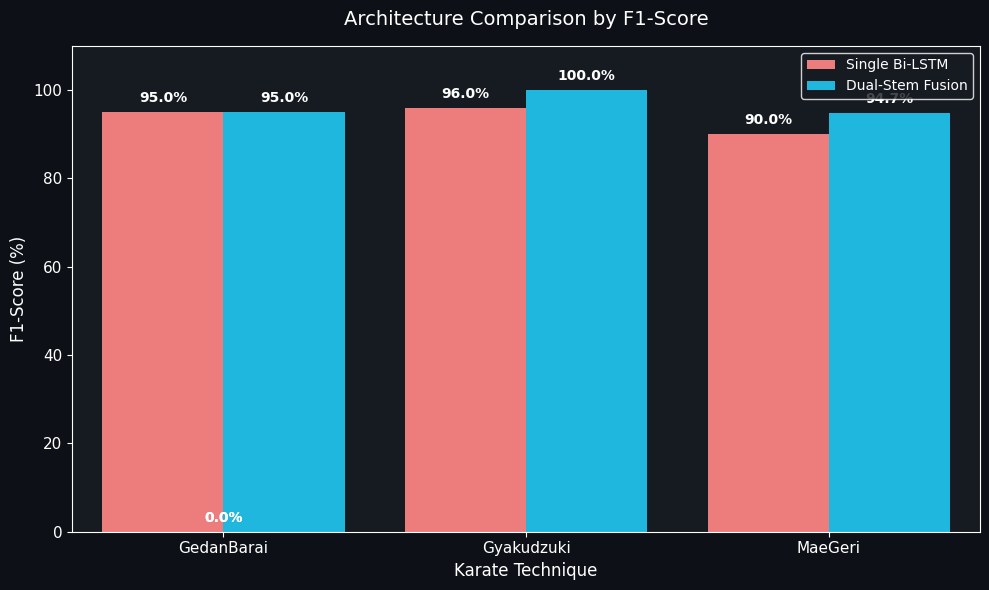


📊 F1-Score Improvement Summary:
Technique          Old F1   New F1    Delta
--------------------------------------------
GedanBarai          95.0%    95.0%  ▼0.0%
Gyakudzuki          96.0%   100.0%  ▲4.0%
MaeGeri             90.0%    94.7%  ▲4.7%

✅ Metadata saved to: D:\CS-Senior26'\GR\martial-arts-trainer\backend\app\models\Results\Run_May24_0044\model_metadata.json
🏁 COMPLETE! All models and reports are secured in the Run folder.


In [9]:


# ==============================================================================
# ── 8. FINAL COMPARISON EXPORT (CSV, Plot, JSON) ──────────────────────────────
# ==============================================================================
print("\n📊 Generating Final Comparison Reports...")

report_new = classification_report(y_true, y_pred_new, target_names=CLASS_NAMES, output_dict=True)
report_old = classification_report(y_true, y_pred_old, target_names=CLASS_NAMES, output_dict=True)

comparison_data = []
csv_stats = []

for cls in CLASS_NAMES:
    old_f1 = report_old[cls]['f1-score'] * 100
    new_f1 = report_new[cls]['f1-score'] * 100
    
    comparison_data.append({'Technique': cls, 'F1-Score': old_f1, 'Model': 'Single Bi-LSTM'})
    comparison_data.append({'Technique': cls, 'F1-Score': new_f1, 'Model': 'Dual-Stem Fusion'})
    
    csv_stats.append({
        'Technique': cls,
        'Support': report_new[cls]['support'],
        'Baseline_F1': round(old_f1, 2),
        'DualStem_F1': round(new_f1, 2),
        'Delta_Improvement': round(new_f1 - old_f1, 2),
        'Precision': round(report_new[cls]['precision'] * 100, 2),
        'Recall': round(report_new[cls]['recall'] * 100, 2)
    })

# Save CSV
csv_path = os.path.join(RUN_SAVE_DIR, 'detailed_performance_report.csv')
pd.DataFrame(csv_stats).to_csv(csv_path, index=False)
print(f"📄 CSV Report saved: {csv_path}")

# Plot Comparison
plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor('#161B22')

sns.barplot(
    data=pd.DataFrame(comparison_data),
    x='Technique', y='F1-Score', hue='Model',
    palette={'Single Bi-LSTM': '#FF6B6B', 'Dual-Stem Fusion': '#00C9FF'},
    ax=ax
)

plt.title('Architecture Comparison by F1-Score', color='white', fontsize=14, pad=15)
plt.ylabel('F1-Score (%)', color='white', fontsize=12)
plt.xlabel('Karate Technique', color='white', fontsize=12)
plt.ylim(0, 110)
plt.tick_params(colors='white', labelsize=11)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', color='white', fontweight='bold')

plt.legend(facecolor='#161B22', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(RUN_SAVE_DIR, 'model_comparison.png'), dpi=150, facecolor=BG_COLOR)
plt.show()

# Print Delta Summary
print("\n📊 F1-Score Improvement Summary:")
print(f"{'Technique':<16} {'Old F1':>8} {'New F1':>8} {'Delta':>8}")
print("-" * 44)
for row in csv_stats:
    delta = row['Delta_Improvement']
    symbol = '▲' if delta > 0 else '▼'
    print(f"{row['Technique']:<16} {row['Baseline_F1']:>7.1f}% {row['DualStem_F1']:>7.1f}%  {symbol}{abs(delta):.1f}%")

# Save Metadata JSON
meta_path = os.path.join(RUN_SAVE_DIR, 'model_metadata.json')
meta = {
    'classes': CLASS_NAMES,
    'seq_len': SEQ_LEN,
    'dual_stem_accuracy': float(test_acc),
    'trained_at': datetime.datetime.now().isoformat()
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ Metadata saved to: {meta_path}")
print("🏁 COMPLETE! All models and reports are secured in the Run folder.")